# **I. Business Understanding**
### **Background**

Customer churn is a major challenge for telecommunication companies. Acquiring new customers is often more expensive than retaining existing ones, making customer retention a critical factor for long-term business growth and profitability.

The company has observed a significant number of customers discontinuing its services, leading to revenue loss and increased customer acquisition costs. Understanding the factors that contribute to churn is essential for developing effective retention strategies.

### **Business Problem**

The company wants to identify the key drivers of customer churn and understand which customer segments are most likely to leave. By gaining these insights, the business can implement targeted retention initiatives to reduce customer attrition.

### **Project Objectives**

The objectives of this project are:

* Analyze customer characteristics associated with churn.
* Identify the most influential factors affecting customer retention.
* Explore customer churn reasons and categories.
* Discover high-risk customer groups with elevated churn rates.
* Provide actionable recommendations to improve customer retention and reduce churn.

### **Success Criteria**

The project will be considered successful if it can:

* Reveal the main factors driving customer churn.
* Identify customer segments with the highest churn risk.
* Generate actionable business recommendations based on data-driven insights.
* Support decision-making for customer retention strategies.

# **II. Data Processing**

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
from google.colab import drive
drive.mount('/content/ggdrive')

path = ('/content/ggdrive/MyDrive/Data Analyst/Python Projects/Telco Customer Churn/')

telco = pd.read_excel(path + '/data/Telco_customer_churn.xlsx')

Drive already mounted at /content/ggdrive; to attempt to forcibly remount, call drive.mount("/content/ggdrive", force_remount=True).


## **1. Overview**

In [97]:
telco.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [98]:
telco.shape


(7043, 33)

In [99]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Need to change type of Total Charges

In [100]:
# Change type of Total Charges
telco['Total Charges'] = pd.to_numeric(telco['Total Charges'], errors = 'coerce')
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [101]:
telco.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


## **2. Check for Missing Value**

In [102]:
telco.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [103]:
# Check 11 null rowws

telco[telco['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


These 11 data rows have Tenure Months = 0 -> New Customers. Therefore, Total Charges are considered to be 0

In [104]:
# Assign the value 0 to 11 rows containing null values
telco['Total Charges'] = telco['Total Charges'].fillna(0)

# Check for null
telco[telco['Total Charges'].isna()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason


# **III. EDA**

## **1. Overview Analysis**

In [105]:
# Total Customers
total_customers = len(telco)

# Churned Customers
churned_customers = (telco['Churn Label'] == 'Yes').sum()

# Churn Rate
churn_rate = (churned_customers / total_customers) * 100

print(f'Total Customers: {total_customers}')
print(f'Churned Customers: {churned_customers}')
print(f'Churn Rate: {churn_rate:.2f}%')

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54%


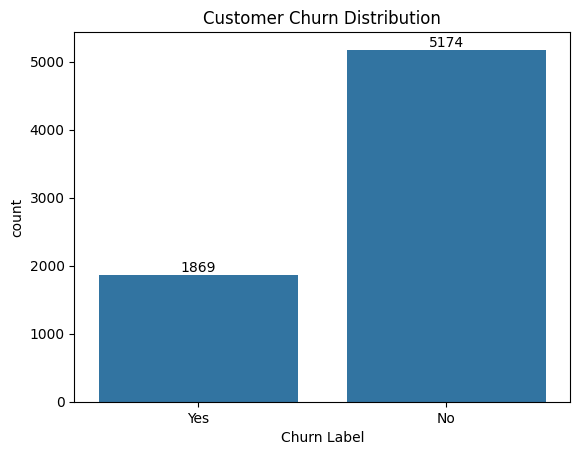

In [106]:
# Visualization
sns.countplot(data = telco, x = 'Churn Label')
plt.title('Customer Churn Distribution')
plt.bar_label(plt.gca().containers[0])
plt.show()

The company has a churn rate of approximately 26.54%, meaning that for every 100 customers, nearly 27 stop using the service. This is a relatively high number, especially in the telecommunications industry, because customers tend to have long-term contracts with the company they subscribe to.

## **2. Churn Analysis**

### **2.1 Churn Rate by Contract**

In [107]:
# Calculate churn rate by contract
contract_churn = pd.crosstab(telco['Contract'], telco['Churn Label'], normalize = 'index') * 100
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


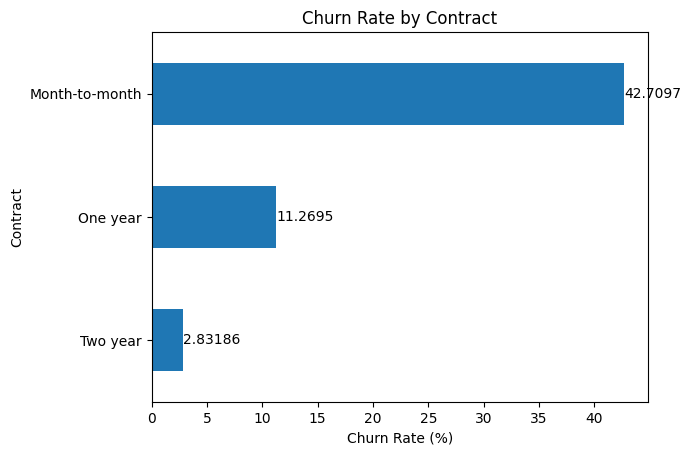

In [108]:
# Visualization
contract_churn['Yes'].sort_values().plot(kind = 'barh')
plt.title('Churn Rate by Contract')
plt.xlabel('Churn Rate (%)')
plt.bar_label(plt.gca().containers[0])
plt.show()

Customers using month-to-month contracts have the highest churn rate among the three contract types, while customers using two-year contracts have the lowest churn rate.

-> Long-term service commitment helps reduce customer churn rates.

### **2.2 Churn Rate by Tenure**

In [109]:
# Group Tenure into 0-12, 13-24, 25-40, 49-72
telco['Tenure Group'] = pd.cut(telco['Tenure Months'], bins = [0, 12, 24, 48, 72], labels = ['0 - 12', '13 - 24', '25 - 48', '49 - 72'])

# Calculate churn rate by Tenure
tenure_churn_rate = pd.crosstab(telco['Tenure Group'], telco['Churn Label'], normalize = 'index') * 100
tenure_churn_rate

Churn Label,No,Yes
Tenure Group,,
0 - 12,52.321839,47.678161
13 - 24,71.289062,28.710938
25 - 48,79.611041,20.388959
49 - 72,90.486824,9.513176


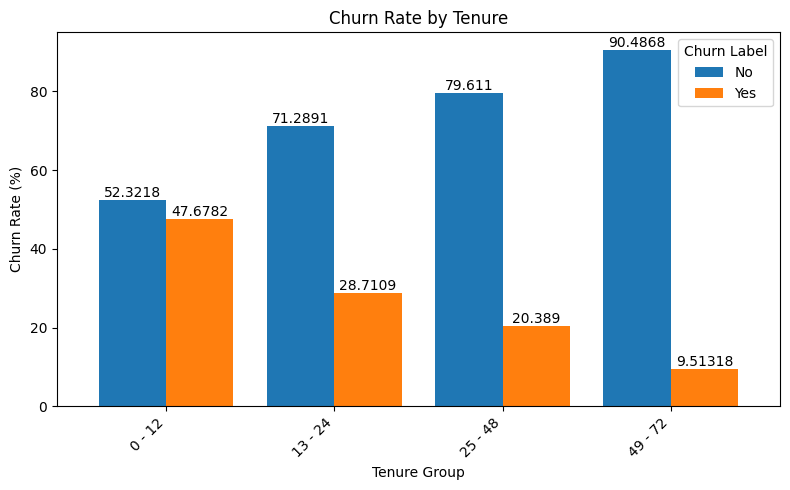

In [110]:
# Visualization
tenure_churn_rate.plot(kind = 'bar', figsize = (8, 5), width = 0.8)
plt.title('Churn Rate by Tenure')
plt.ylabel('Churn Rate (%)')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.xticks(rotation = 45, ha = 'right')
plt.legend(title = 'Churn Label')
plt.tight_layout()
plt.show()

Churn rate is inversely proportional to the length of time a customer uses a service, meaning the longer a customer uses a service, the harder it is for them to leave.

Customers using the service in the first year have the highest churn rate, which decreases significantly in the second year.

-> The majority of customers stop using the service in the early stages of the customer lifecycle.

### **2.3 Churn Rate by Contract and Tenure**

In [111]:
# Calculate churn rate by Contract and Tenure
contract_tenure_churn = pd.pivot_table(telco, values = 'Churn Value', index = 'Tenure Group', columns = 'Contract', aggfunc = 'mean') * 100
contract_tenure_churn

/tmp/ipykernel_6229/1970853664.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  contract_tenure_churn = pd.pivot_table(telco, values = 'Churn Value', index = 'Tenure Group', columns = 'Contract', aggfunc = 'mean') * 100


Contract,Month-to-month,One year,Two year
Tenure Group,,,
0 - 12,51.354062,10.569106,0.000000
13 - 24,37.720488,8.121827,0.000000
25 - 48,32.917706,10.617761,2.189781
49 - 72,26.023392,12.933754,3.325416


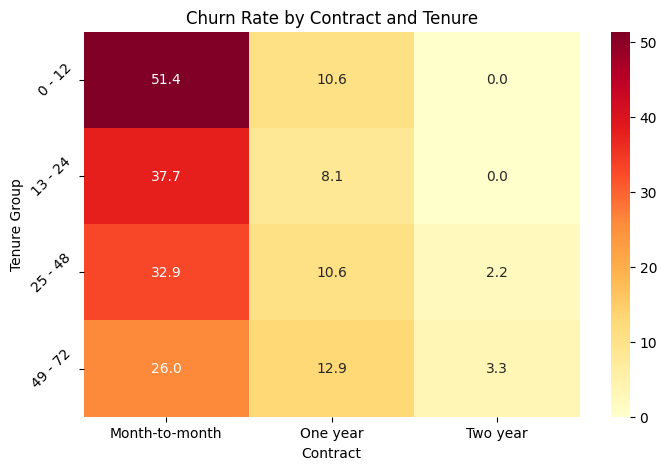

In [112]:
# Visualization
plt.figure(figsize = (8, 5))
sns.heatmap(contract_tenure_churn, annot = True, cmap = 'YlOrRd', fmt = '.1f')
plt.title('Churn Rate by Contract and Tenure')
plt.yticks(rotation = 45, va = 'center')
plt.show()

The month-to-month customer segment has a higher churn rate than other segments, especially those using the service for the first 12 months, which has the highest churn rate at 51.4%. This is the high-risk customer segment.

### **2.4 Churn Rate by Monthly Charges**

In [113]:
# Calculate mean and median of Monthly Charges by Churn Label
telco.groupby('Churn Label')['Monthly Charges'].agg(['mean','median'])

,mean,median
Churn Label,,
No,61.265124,64.425
Yes,74.441332,79.650


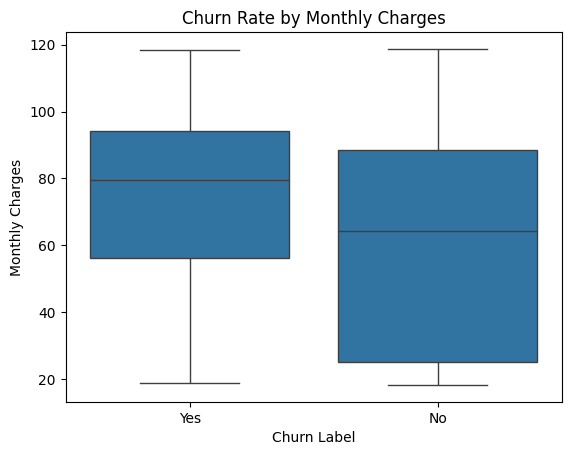

In [114]:
sns.boxplot(data = telco, x = 'Churn Label', y = 'Monthly Charges')
plt.title('Churn Rate by Monthly Charges')
plt.ylabel('Monthly Charges')
plt.show()

Customers with high churn rates typically pay higher fees, with an average difference of approximately $13 per month.

### **2.5 Churn Rate by Contract and Monthly Charges**

In [115]:
# Create Charge Groups
telco['Charge Group'] = pd.qcut(telco['Monthly Charges'], q = 4, labels = ['Low', 'Medium', 'High', 'Very High'])

# Calculate churn rate by Contract and Monthly Charges
contract_charge_churn = pd.pivot_table(telco, values = 'Churn Value', index = 'Charge Group', columns = 'Contract', aggfunc = 'mean') * 100
contract_charge_churn

/tmp/ipykernel_6229/421989501.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  contract_charge_churn = pd.pivot_table(telco, values = 'Churn Value', index = 'Charge Group', columns = 'Contract', aggfunc = 'mean') * 100


Contract,Month-to-month,One year,Two year
Charge Group,,,
Low,25.034578,3.045685,0.775194
Medium,35.617674,8.625337,2.447552
High,53.282182,11.068702,1.552795
Very High,52.183908,20.852018,7.013575


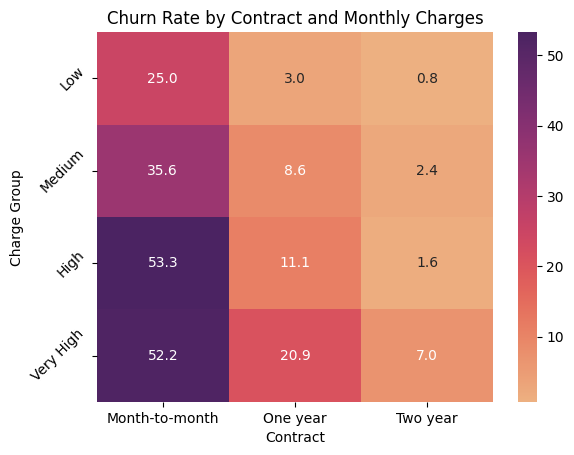

In [116]:
# Visualization
sns.heatmap(contract_charge_churn, annot = True, cmap = 'flare',fmt = '.1f')
plt.title('Churn Rate by Contract and Monthly Charges')
plt.yticks(rotation = 45, va = 'center')
plt.show()

Customers with higher monthly charges have a higher churn rate in the month-to-month group.

-> Significant impact of service pricing on customers without long-term commitment.

### **2.6 Churn Rate by Payment Method**

In [117]:
# Calculate churn rate by Payment Method
payment_method_churn_rate = pd.crosstab(telco['Payment Method'], telco['Churn Label'], normalize = 'index') * 100
payment_method_churn_rate

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


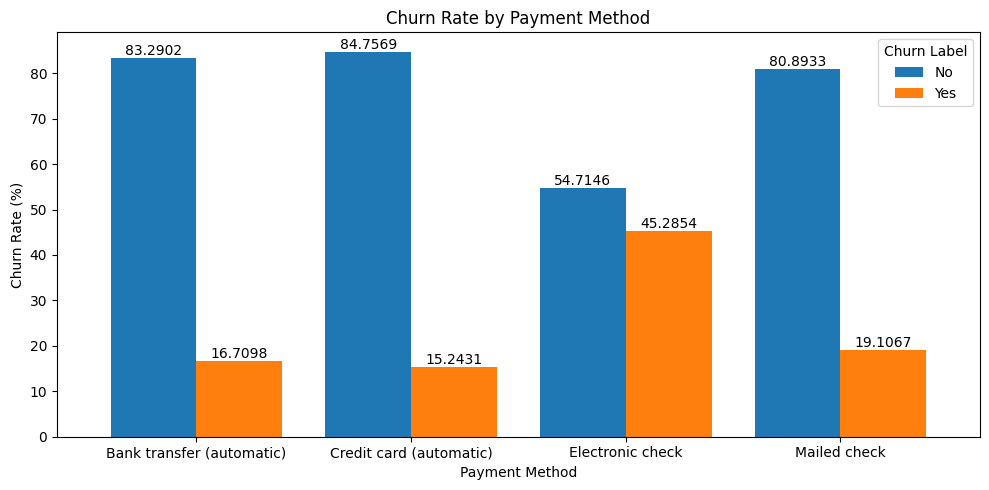

In [118]:
# Visualization
payment_method_churn_rate.plot(kind = 'bar', figsize = (10, 5), width = 0.8)
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.xticks(rotation = 0, ha = 'center')
plt.legend(title = 'Churn Label')
plt.tight_layout()
plt.show()

Customers using electronic checks have a higher churn rate compared to other payment methods, possibly due to the inconvenience of manual operation and verification.

-> Encourage customers to use automated payment methods such as bank transfer or credit card.

### **2.7 Churn Rate by Internet Service**

In [119]:
# Calculate churn rate by Internet Service
internet_service_churn_rate = pd.crosstab(telco['Internet Service'], telco['Churn Label'], normalize = 'index') * 100
internet_service_churn_rate

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


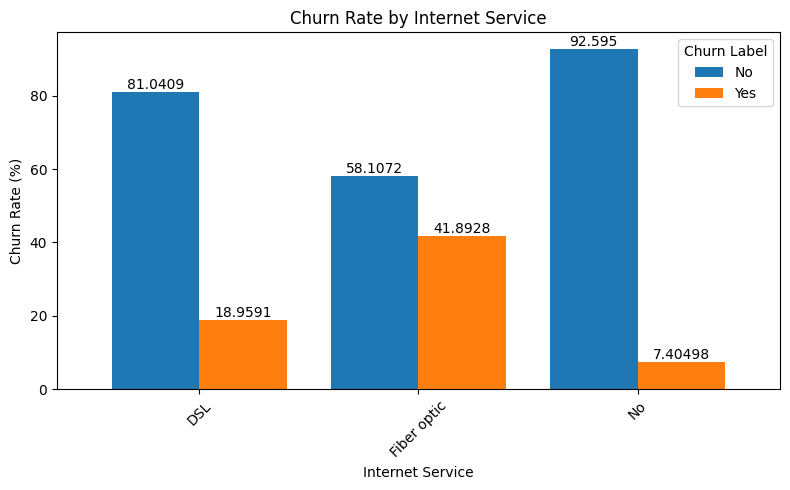

In [120]:
# Visualization
internet_service_churn_rate.plot(kind = 'bar', figsize = (8, 5), width = 0.8)
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.bar_label(plt.gca().containers[0])
plt.bar_label(plt.gca().containers[1])
plt.xticks(rotation = 45, ha = 'center')
plt.legend(title = 'Churn Label')
plt.tight_layout()
plt.show()

Fiber Optic customers experience a higher churn rate compared to DSL, despite it being a modern and popular service with significantly higher speeds.

-> This is due to higher customer expectations for Fiber Optic or issues encountered during service use such as cable breaks, slow speeds during peak hours, etc.

### **2.8 Churn Rate by Tech Support**

In [121]:
# Calculate churn rate by Tech Support
support_churn_rate = pd.crosstab(telco['Tech Support'], telco['Churn Label'], normalize = 'index') * 100
support_churn_rate

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


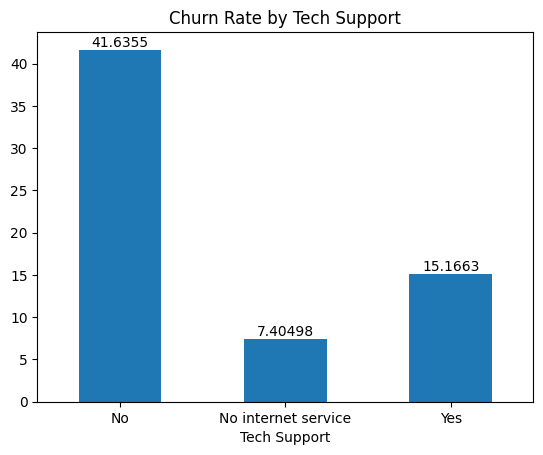

In [122]:
# Visualization
support_churn_rate['Yes'].plot(kind = 'bar')
plt.title('Churn Rate by Tech Support')
plt.bar_label(plt.gca().containers[0])
plt.xticks(rotation = 0, ha = 'center')
plt.show()

Customers who do not use Tech Support have a significantly higher churn rate. However, customers who do use Tech Support still have a churn rate of around 15%.

-> Technical support plays a crucial role in customer retention, but the quality of support services needs improvement.

## **3. Churn Driver Analysis**

### **3.1 Top Churn Reasons**

In [123]:
# Top 10 Reason
top_reason = telco[telco['Churn Label'] == 'Yes']['Churn Reason'].value_counts().head(10)
top_reason

,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


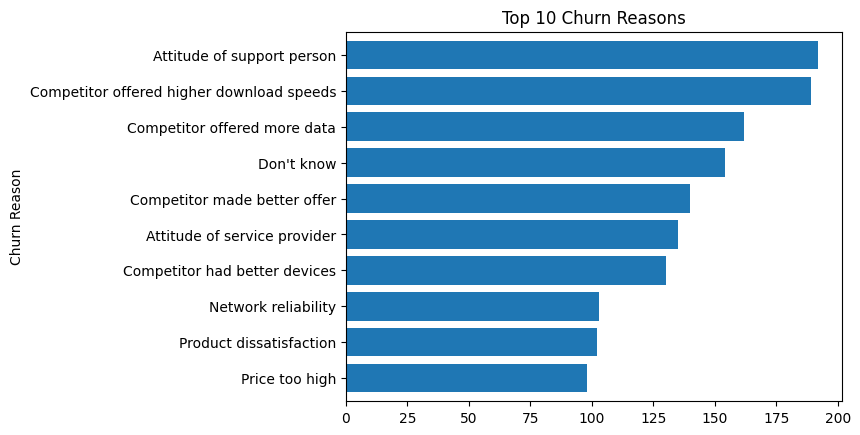

In [124]:
# Visualization
top_reason.sort_values().plot(kind = 'barh', width = 0.8)
plt.title('Top 10 Churn Reasons')
plt.show()

In general, the most common reasons why customers stop using a service relate to competitors, attitude of customer supports, and service quality.

### **3.2. Churn Reason Category Distribution**

In [125]:
# Create Churn Reason Category
reason_mappinng = {
    'Competitor made better offer' : 'Competitor',
    'Competitor had better devices' : 'Competitor',
    'Competitor offered higher download speeds' : 'Competitor',
    'Competitor offered more data' : 'Competitor',

    'Attitude of service provider' : 'Customer Service',
    'Attitude of support person' : 'Customer Service',
    'Poor expertise of online support' : 'Customer Service',
    'Poor expertise of phone support' : 'Customer Service',

    'Price too high' : 'Price',
    'Long distance charges' : 'Price',
    'Extra data charges' : 'Price',

    'Product dissatisfaction' : 'Service Quality',
    'Service dissatisfaction' : 'Service Quality',
    'Lack of self-service on Website' : 'Service Quality',
    'Lack of affordable download/upload speed' : 'Service Quality',
    'Network reliability' : 'Service Quality',
    'Limited range of services' : 'Service Quality',

    'Moved' : 'Personal',
    'Don\'t know' : 'Personal',
    'Deceased' : 'Personal'
}

telco['Churn Reason Category'] = telco['Churn Reason'].map(reason_mappinng)

# Calculate total number of reasons for each category
churn_reason_category = telco[telco['Churn Label'] == 'Yes']['Churn Reason Category'].value_counts()
churn_reason_category

,count
Churn Reason Category,
Competitor,621
Service Quality,470
Customer Service,366
Personal,213
Price,199


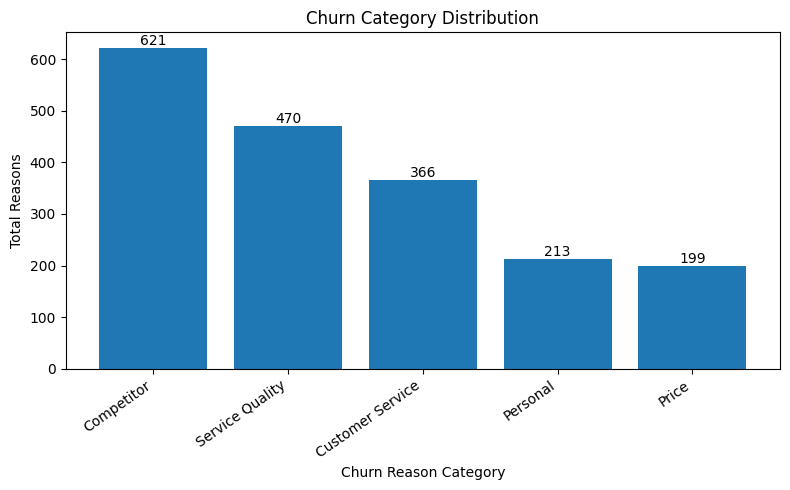

In [126]:
# Visualization
churn_reason_category.plot(kind = 'bar', figsize = (8, 5), width = 0.8)
plt.title('Churn Category Distribution')
plt.ylabel('Total Reasons')
plt.xticks(rotation = 35, ha = 'right')
plt.bar_label(plt.gca().containers[0])
plt.tight_layout()
plt.show()

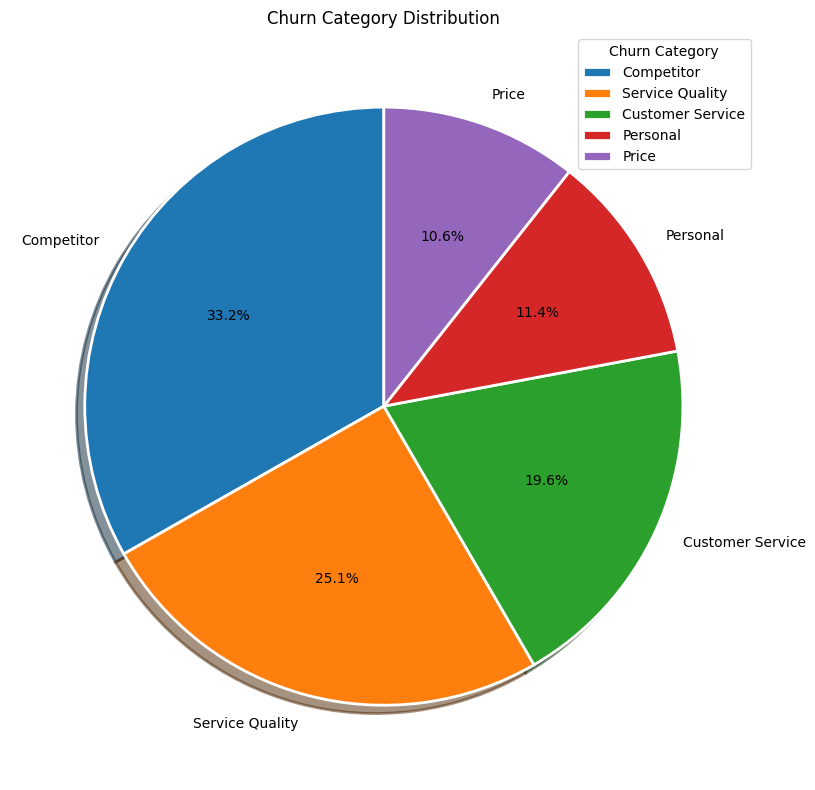

In [127]:
churn_reason_category.plot(kind = 'pie', figsize = (10, 8), autopct = '%.1f%%', startangle = 90, wedgeprops = {'linewidth': 2, 'edgecolor': 'white'}, shadow = True)
plt.title('Churn Category Distribution')
plt.ylabel('')
plt.legend(title = 'Churn Category')
plt.tight_layout()
plt.show()

* Competitors are the biggest reason for customers quitting services.

* In addition, service quality and customer support are also reasons for high churn rates.

# IV. **Key Findings & Business Recommendations**

**1. Customers using Month-to-Month Contracts Exhibit the Highest Churn Rate**

💡 **Recommendation:** Encourage customers to switch to one-year or two-year contracts.

🔹 **Actions**

* Offer 1-2 months of free service for customers who sign long-term contracts.
* Launch seasonal promotional campaigns.
* Implement a customer loyalty program to reward long-term commitment.

---

**2. Nearly Half of Customer Churn Occurs Within the First Year**

💡 **Recommendation:** Focus retention efforts on the early stages of the customer lifecycle.

🔹 **Actions**

* Send welcome emails with service guides and support contact information.
* Conduct monthly follow-up calls to check customer satisfaction and address potential issues.

---

**3. Customers with Higher Monthly Charges Tend to Churn More Frequently**

💡 **Recommendation:** Reassess the value proposition offered to high-paying customers.

🔹 **Actions**

* Develop more flexible pricing plans tailored to different customer segments.
* Provide additional benefits and exclusive offers for premium customers.

---

**4. Fiber Optic Service Shows an Unusually High Churn Rate**

💡 **Recommendation:** Improve the quality of Fiber Optic services and enhance the overall customer experience.

🔹 **Actions**

* Investigate potential technical issues affecting service quality.
* Monitor and analyze customer support requests related to Fiber Optic services.

---

**5. Tech Support Significantly Reduces Customer Churn**

💡 **Recommendation:** Integrate Tech Support into existing service packages instead of offering it as a standalone package.

🔹 **Actions**

* Include Tech Support in packages while adjusting pricing accordingly to improve retention.
* Offer on-site technical assistance for customers who require additional support.

---

**6. Competitors Are the Primary Driver of Customer Churn**

💡 **Recommendation:** Develop customer retention programs to prevent customers from switching to competitors.

🔹 **Actions**

* Introduce a loyalty rewards system with points and exclusive benefits.
* Identify high-risk customers and provide personalized retention offers before they leave.